In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Phase 1: Data Loading
import pandas as pd
import numpy as np

BASE = '/kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/'

student_info        = pd.read_csv(BASE + 'studentInfo.csv')
student_registration = pd.read_csv(BASE + 'studentRegistration.csv')
student_assessment  = pd.read_csv(BASE + 'studentAssessment.csv')
assessments         = pd.read_csv(BASE + 'assessments.csv')
student_vle         = pd.read_csv(BASE + 'studentVle.csv')
vle                 = pd.read_csv(BASE + 'vle.csv')
courses             = pd.read_csv(BASE + 'courses.csv')

# Shape check
for name, df in [('student_info', student_info), 
                 ('student_registration', student_registration),
                 ('student_assessment', student_assessment), 
                 ('assessments', assessments),
                 ('student_vle', student_vle), 
                 ('vle', vle), 
                 ('courses', courses)]:
    print(f"{name:25s}: {df.shape}  | columns: {list(df.columns)}")

student_info             : (32593, 12)  | columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
student_registration     : (32593, 5)  | columns: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']
student_assessment       : (173912, 5)  | columns: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']
assessments              : (206, 6)  | columns: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
student_vle              : (10655280, 6)  | columns: ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']
vle                      : (6364, 6)  | columns: ['id_site', 'code_module', 'code_presentation', 'activity_type', 'week_from', 'week_to']
courses                  : (22, 3)  | columns: ['code_module', 'code_presentati

In [3]:
# Phase 2: Feature Engineering

# --- 2a. VLE Features (from student_vle) ---
vle_features = student_vle.groupby('id_student').agg(
    total_clicks        = ('sum_click', 'sum'),
    active_days         = ('date', 'nunique'),
    avg_clicks_per_day  = ('sum_click', 'mean'),
    max_clicks_day      = ('sum_click', 'max'),
    early_clicks        = ('sum_click', lambda x: x[student_vle.loc[x.index, 'date'] <= 30].sum()),
).reset_index()

In [8]:
# --- 2b. Assessment Features ---
# Merge assessment metadata to get due date
assess_merged = student_assessment.merge(assessments[['id_assessment', 'date', 'assessment_type']], 
                                          on='id_assessment', how='left')
# Days early/late = due date - submitted date (positive = submitted early)
assess_merged['days_early'] = assess_merged['date'] - assess_merged['date_submitted']

assess_features = assess_merged.groupby('id_student').agg(
    avg_score               = ('score', 'mean'),
    min_score               = ('score', 'min'),
    num_assessments         = ('id_assessment', 'count'),
    avg_days_early          = ('days_early', 'mean'),
    num_late_submissions    = ('days_early', lambda x: (x < 0).sum()),
).reset_index()

In [9]:
# --- 2c. Registration Features ---
reg_features = student_registration[['id_student', 'date_registration', 'date_unregistration']].copy()
reg_features['unregistered'] = reg_features['date_unregistration'].notna().astype(int)

In [10]:

# --- 2d. Merge everything onto student_info ---
df = student_info.copy()
df = df.merge(vle_features,   on='id_student', how='left')
df = df.merge(assess_features, on='id_student', how='left')
df = df.merge(reg_features[['id_student', 'date_registration', 'unregistered']], 
              on='id_student', how='left')

In [11]:
# --- 2e. Target variable ---
# Binary: 1 = Withdrawn or Fail, 0 = Pass or Distinction
df['dropout'] = df['final_result'].isin(['Withdrawn', 'Fail']).astype(int)

print(df.shape)
print(df['dropout'].value_counts())
print(df.isnull().sum())

(40801, 25)
dropout
1    22495
0    18306
Name: count, dtype: int64
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1401
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
total_clicks            3152
active_days             3152
avg_clicks_per_day      3152
max_clicks_day          3152
early_clicks            3152
avg_score               6794
min_score               6794
num_assessments         6773
avg_days_early          6773
num_late_submissions    6773
date_registration         64
unregistered               0
dropout                    0
dtype: int64


In [12]:
# Phase 3: Clean, Impute & Encode

# --- 3a. Fill VLE nulls with 0 (never engaged = 0 clicks) ---
vle_cols = ['total_clicks', 'active_days', 'avg_clicks_per_day', 'max_clicks_day', 'early_clicks']
df[vle_cols] = df[vle_cols].fillna(0)

# --- 3b. Fill assessment nulls with 0 ---
assess_cols = ['avg_score', 'min_score', 'num_assessments', 'avg_days_early', 'num_late_submissions']
df[assess_cols] = df[assess_cols].fillna(0)

# --- 3c. Fill imd_band nulls with mode ---
df['imd_band'] = df['imd_band'].fillna(df['imd_band'].mode()[0])

# --- 3d. Drop the 64 missing registration rows ---
df = df.dropna(subset=['date_registration'])

print(f"Shape after cleaning: {df.shape}")
print(f"Nulls remaining: {df.isnull().sum().sum()}")
print(f"\nDropout distribution:\n{df['dropout'].value_counts()}")
print(f"Class balance: {df['dropout'].mean():.2%} dropout rate")

# --- 3e. Encode categoricals ---
cat_cols = ['code_module', 'code_presentation', 'gender', 'region',
            'highest_education', 'imd_band', 'age_band', 'disability']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# --- 3f. Define features and target ---
drop_cols = ['id_student', 'final_result', 'dropout']
X = df_encoded.drop(columns=drop_cols)
y = df_encoded['dropout']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Shape after cleaning: (40737, 25)
Nulls remaining: 0

Dropout distribution:
dropout
1    22435
0    18302
Name: count, dtype: int64
Class balance: 55.07% dropout rate

Feature matrix shape: (40737, 52)
Target shape: (40737,)


In [14]:
# Fix column names - remove brackets and special characters
X.columns = X.columns.str.replace('[', '', regex=False)\
                      .str.replace(']', '', regex=False)\
                      .str.replace('<', '', regex=False)\
                      .str.replace('>', '', regex=False)\
                      .str.replace(' ', '_', regex=False)

# Verify no bad characters remain
bad = [c for c in X.columns if any(ch in c for ch in ['[', ']', '<', '>'])]
print(f"Bad column names remaining: {bad}")
print(f"Sample columns: {list(X.columns[:5])}")

Bad column names remaining: []
Sample columns: ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'active_days', 'avg_clicks_per_day']


Train: (32589, 52) | Test: (8148, 52)
scale_pos_weight: 0.816
[0]	validation_0-auc:0.92875
[50]	validation_0-auc:0.96355
[100]	validation_0-auc:0.96897
[150]	validation_0-auc:0.97195
[200]	validation_0-auc:0.97387
[250]	validation_0-auc:0.97511
[299]	validation_0-auc:0.97604

ROC-AUC: 0.9760

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      3661
           1       0.96      0.89      0.93      4487

    accuracy                           0.92      8148
   macro avg       0.92      0.92      0.92      8148
weighted avg       0.92      0.92      0.92      8148



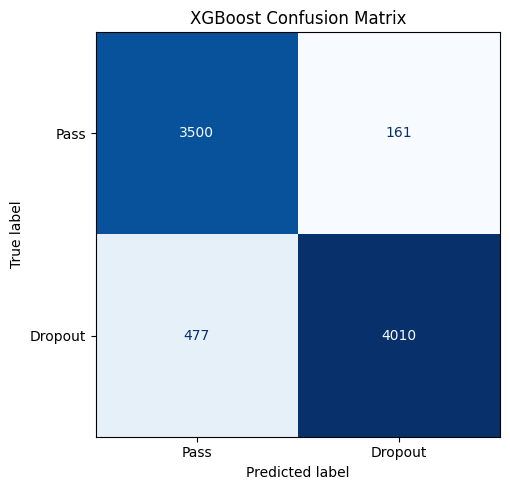

In [15]:
# Phase 4: XGBoost Model
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score, 
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# --- 4a. Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# --- 4b. Handle class imbalance via scale_pos_weight ---
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.3f}")

# --- 4c. Train XGBoost ---
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# --- 4d. Evaluate ---
y_pred  = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# --- 4e. Confusion Matrix ---
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax,
                                         display_labels=['Pass', 'Dropout'],
                                         colorbar=False, cmap='Blues')
ax.set_title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

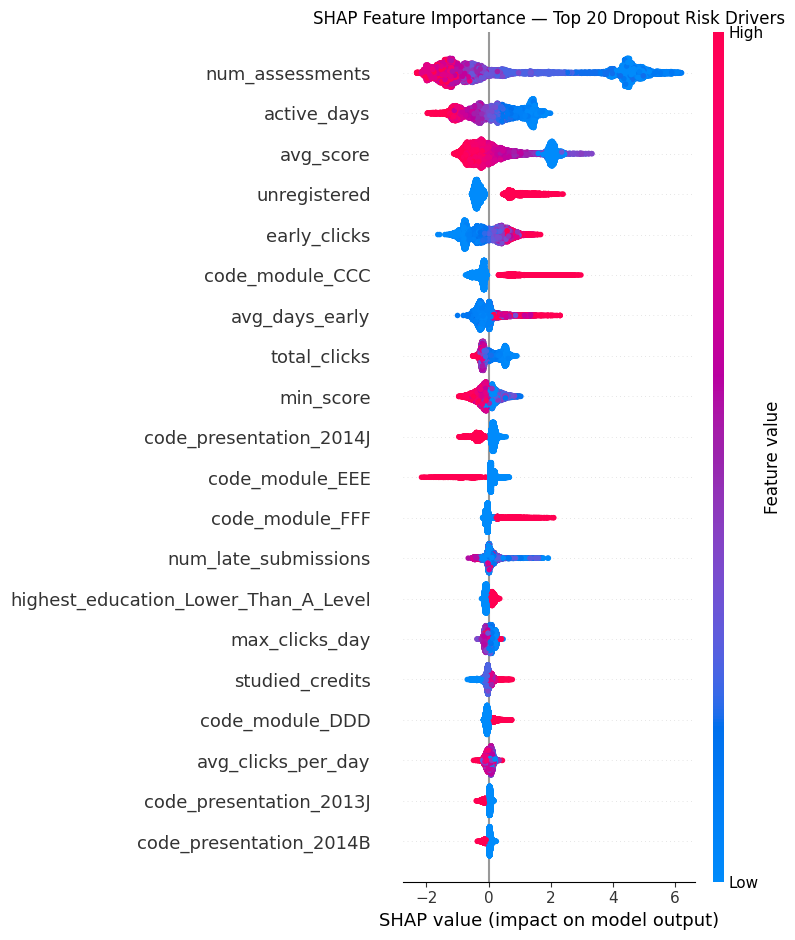

In [17]:
# Phase 5: SHAP Explainability
import shap
import matplotlib.pyplot as plt

# --- 5a. SHAP values ---
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# --- 5b. Global Feature Importance — Beeswarm plot ---
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title("SHAP Feature Importance — Top 20 Dropout Risk Drivers")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

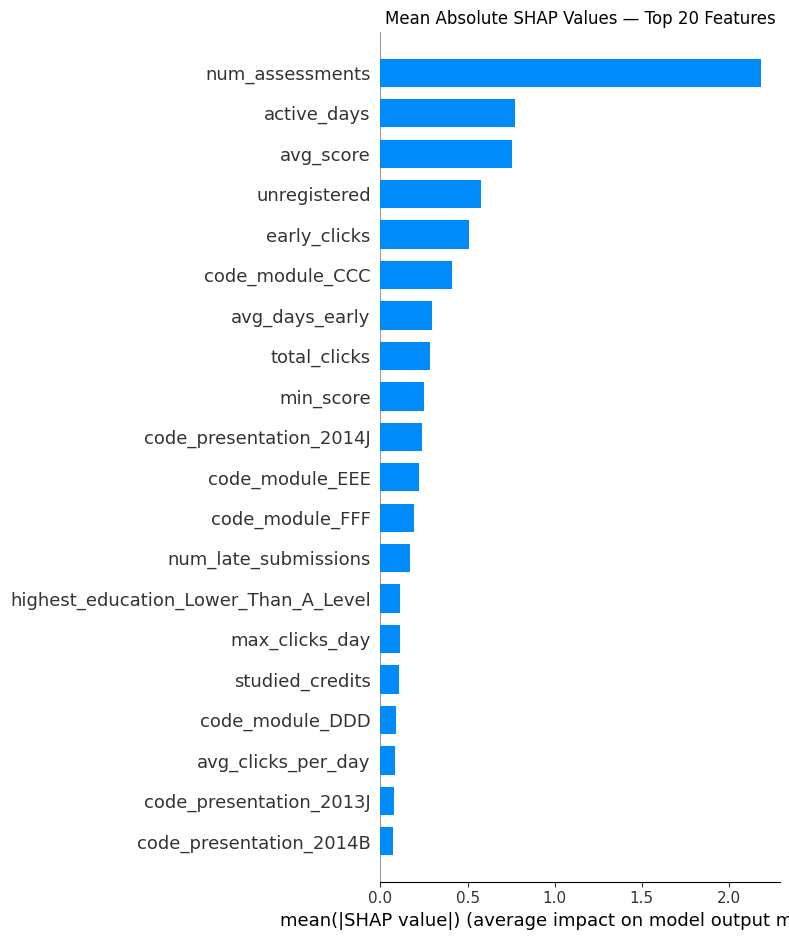

In [18]:
# --- 5c. Bar plot of mean absolute SHAP ---
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', 
                  max_display=20, show=False)
plt.title("Mean Absolute SHAP Values — Top 20 Features")
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
›# --- 5d. Print top 10 features by importance ---
shap_df = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Top 10 Dropout Risk Drivers:")
print(shap_df.head(10).to_string(index=False))

Top 10 Dropout Risk Drivers:
                feature  mean_abs_shap
        num_assessments       2.183840
            active_days       0.774116
              avg_score       0.757377
           unregistered       0.577226
           early_clicks       0.506092
        code_module_CCC       0.409570
         avg_days_early       0.295384
           total_clicks       0.286350
              min_score       0.252627
code_presentation_2014J       0.238134


# Key findings from SHAP:
#1 num_assessments (SHAP: 2.18) — by far the strongest signal

Low value (blue) → pushes strongly toward dropout (right = high risk)
- Students who attempt fewer assessments are at massive dropout risk
- Makes intuitive sense: disengagement from assessments is the clearest early warning sign

#2 active_days (0.77) & avg_score (0.75)

- Low active days + low scores both push toward dropout
- High values (pink) push toward success

#3 unregistered (0.58)

- Binary flag — if they formally unregistered, obviously high dropout signal
- Good that the model picked this up cleanly

#4 early_clicks (0.51)

- Low early engagement in first 30 days is a strong dropout predictor
- This is the most actionable feature — intervention can happen early

#5 code_module_CCC (0.41)

- Specific course effect — CCC module has higher dropout risk regardless of behavior
- Suggests curriculum-level issues in that module

In [25]:
# Phase 6: Equity Gap Analysis & Hypothesis Testing
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Work on clean df before encoding (has original categorical columns)
equity_df = df[['disability', 'imd_band', 'age_band', 
                'highest_education', 'gender', 'dropout']].copy()

# --- 6a. Helper: chi-square test + dropout rate per group ---
def equity_analysis(df, col, label):
    grouped = df.groupby(col)['dropout'].agg(['mean', 'count']).reset_index()
    grouped.columns = [col, 'dropout_rate', 'count']
    grouped['dropout_rate_pct'] = (grouped['dropout_rate'] * 100).round(1)
    
    # Chi-square test
    contingency = pd.crosstab(df[col], df['dropout'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    
    print(f"\n{'='*50}")
    print(f"Equity Analysis: {label}")
    print(f"{'='*50}")
    print(grouped[[col, 'dropout_rate_pct', 'count']].to_string(index=False))
    print(f"\nChi-square: {chi2:.2f} | p-value: {p:.4f} | DOF: {dof}")
    print(f"Result: {'SIGNIFICANT ✓' if p < 0.05 else 'NOT significant'}")
    
    return grouped

In [23]:

# --- 6b. Run analysis across 4 equity dimensions ---
disability_eq  = equity_analysis(equity_df, 'disability',        'Disability Status')
imd_eq         = equity_analysis(equity_df, 'imd_band',          'IMD Deprivation Band')
age_eq         = equity_analysis(equity_df, 'age_band',          'Age Group')
education_eq   = equity_analysis(equity_df, 'highest_education', 'Highest Education Level')



Equity Analysis: Disability Status
disability  dropout_rate_pct  count
         N              54.0  36582
         Y              64.4   4155

Chi-square: 163.26 | p-value: 0.0000 | DOF: 1
Result: SIGNIFICANT ✓

Equity Analysis: IMD Deprivation Band
imd_band  dropout_rate_pct  count
   0-10%              66.5   4080
   10-20              63.2   4312
  20-30%              55.9   6032
  30-40%              55.1   4417
  40-50%              55.9   4045
  50-60%              53.2   3849
  60-70%              50.6   3648
  70-80%              51.5   3637
  80-90%              48.8   3510
 90-100%              45.2   3207

Chi-square: 567.96 | p-value: 0.0000 | DOF: 9
Result: SIGNIFICANT ✓

Equity Analysis: Age Group
age_band  dropout_rate_pct  count
    0-35              57.0  28933
   35-55              50.7  11508
    55<=              41.6    296

Chi-square: 154.84 | p-value: 0.0000 | DOF: 2
Result: SIGNIFICANT ✓

Equity Analysis: Highest Education Level
          highest_education  d

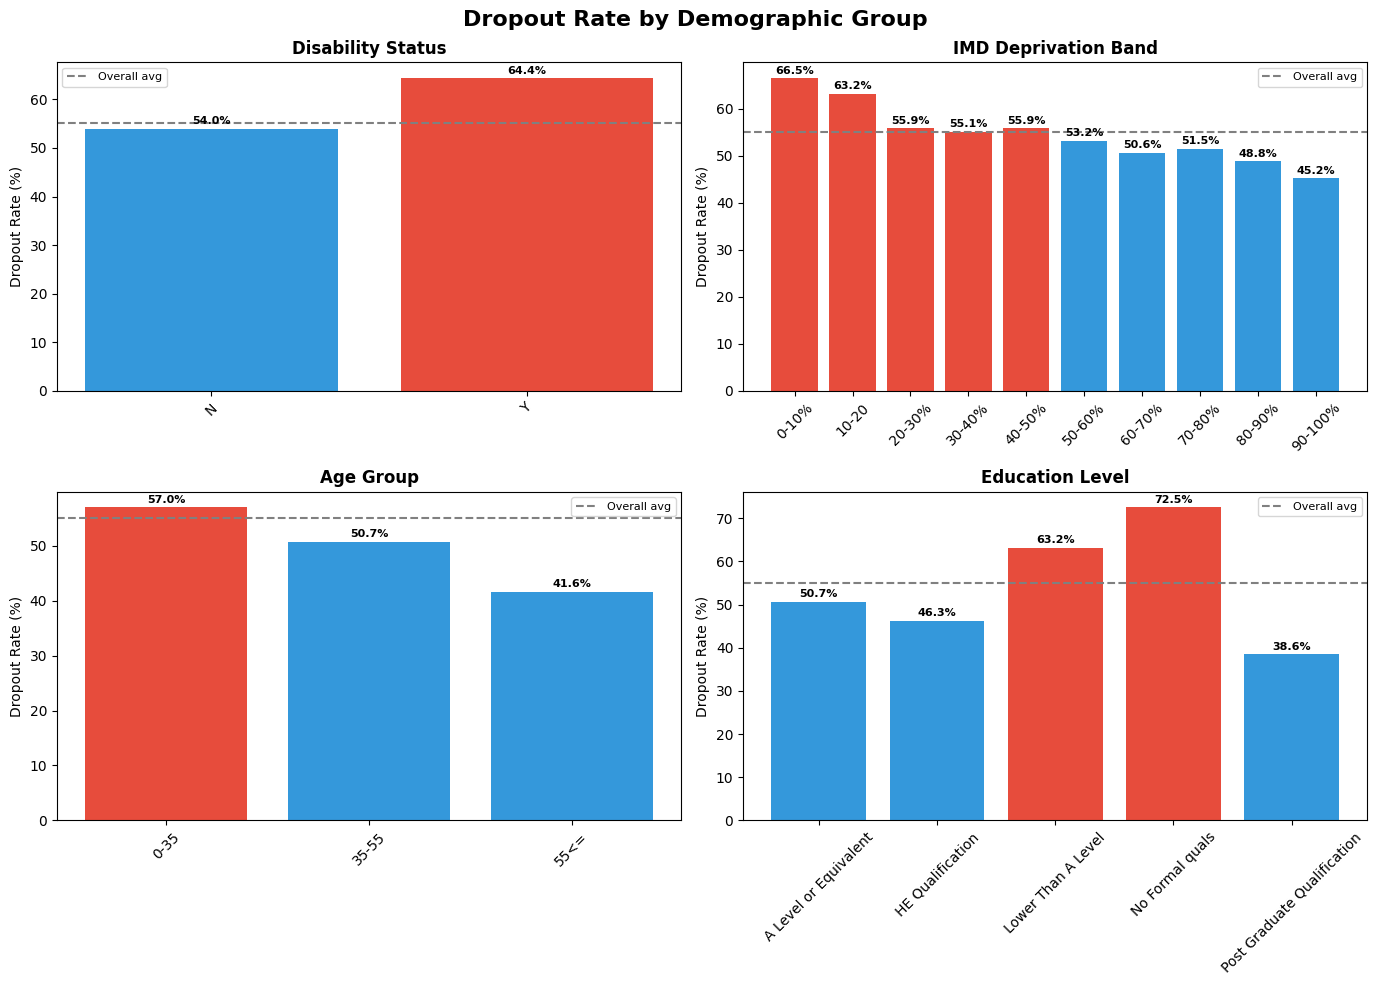

In [24]:
# --- 6c. Visualization: Dropout rate by group ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dropout Rate by Demographic Group', fontsize=16, fontweight='bold')

datasets = [
    (disability_eq,  'disability',        'Disability Status',      axes[0,0]),
    (imd_eq,         'imd_band',          'IMD Deprivation Band',   axes[0,1]),
    (age_eq,         'age_band',          'Age Group',              axes[1,0]),
    (education_eq,   'highest_education', 'Education Level',        axes[1,1]),
]

for data, col, title, ax in datasets:
    bars = ax.bar(data[col].astype(str), data['dropout_rate_pct'], 
                  color=['#e74c3c' if x > 55 else '#3498db' 
                         for x in data['dropout_rate_pct']])
    ax.axhline(y=equity_df['dropout'].mean()*100, color='gray', 
               linestyle='--', linewidth=1.5, label='Overall avg')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Dropout Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    
    # Add value labels on bars
    for bar, val in zip(bars, data['dropout_rate_pct']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('equity_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

# Key Equity Findings:
- Disability: Students with disabilities drop out at **64.4% vs 54.0%** — a 10.4 percentage point gap, statistically significant (p<0.0001)
- IMD Deprivation: Most deprived band (0-10%) drops out at **66.5% vs 45.2%** for least deprived — a 21.3 point gap. Clear socioeconomic gradient across all 10 bands.
- Age: Younger students (0-35) drop out at 57% vs older students (55+) at **41.6%** — older students actually perform better, likely due to higher motivation.
- Education: Students with no formal qualifications drop out at **72.5%** vs postgraduates at **38.6%** — the largest gap at 33.9 points.
**All 4 are statistically significant with p<0.0001.**

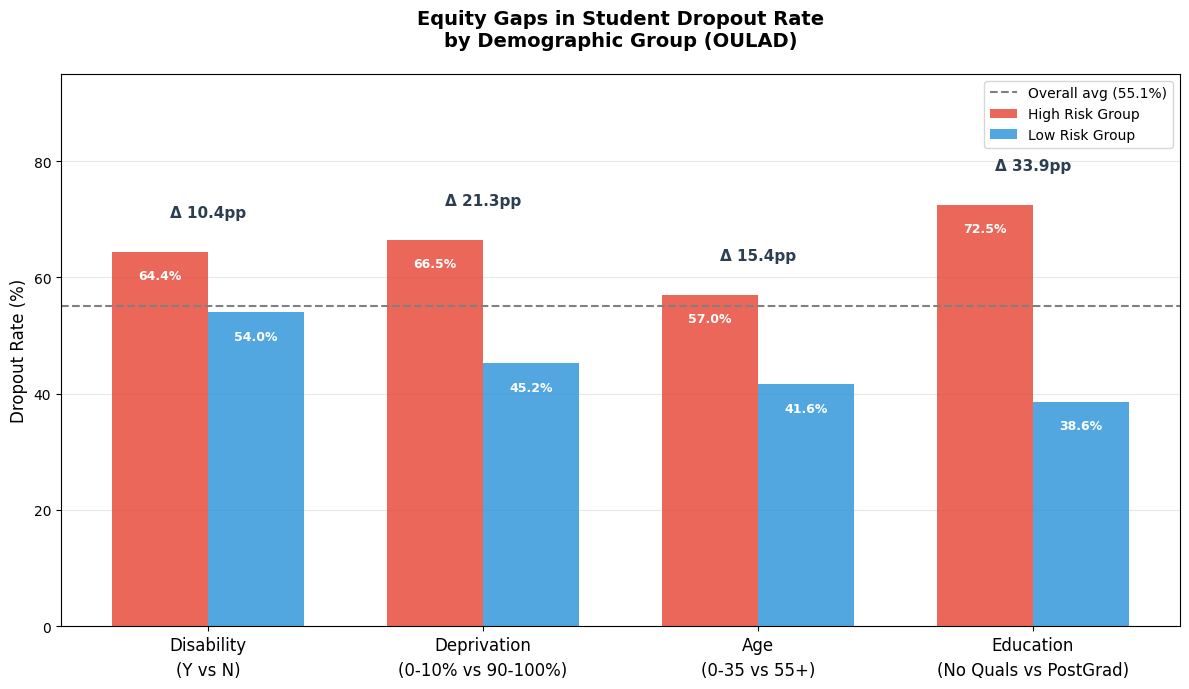

In [27]:
fig, ax = plt.subplots(figsize=(12, 7))

groups = [
    ('Disability\n(Y vs N)',              64.4, 54.0),
    ('Deprivation\n(0-10% vs 90-100%)',   66.5, 45.2),
    ('Age\n(0-35 vs 55+)',                57.0, 41.6),
    ('Education\n(No Quals vs PostGrad)', 72.5, 38.6),
]

labels    = [g[0] for g in groups]
high_risk = [g[1] for g in groups]
low_risk  = [g[2] for g in groups]
gaps      = [h - l for h, l in zip(high_risk, low_risk)]

x     = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, high_risk, width, label='High Risk Group',
               color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, low_risk,  width, label='Low Risk Group',
               color='#3498db', alpha=0.85)

# Value labels INSIDE bars (near top) to avoid overlap
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
            f'{bar.get_height()}%', ha='center', va='top', 
            fontsize=9, color='white', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
            f'{bar.get_height()}%', ha='center', va='top',
            fontsize=9, color='white', fontweight='bold')

# Gap annotations well above both bars
for i, (h, l, gap) in enumerate(zip(high_risk, low_risk, gaps)):
    ax.annotate(f'Δ {gap:.1f}pp',
                xy=(x[i], max(h, l) + 6),
                ha='center', fontsize=11, fontweight='bold', color='#2c3e50')

ax.axhline(y=55.07, color='gray', linestyle='--',
           linewidth=1.5, label='Overall avg (55.1%)')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, linespacing=1.5)
ax.set_ylabel('Dropout Rate (%)', fontsize=12)
ax.set_ylim(0, 95)
ax.set_title('Equity Gaps in Student Dropout Rate\nby Demographic Group (OULAD)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('equity_gap_summary.png', dpi=150, bbox_inches='tight')
plt.show()